In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
# Load station metadata (small)
stations = pd.read_csv("data/stations.csv")

# Load station_day (safe size)
station_day = pd.read_csv("data/station_day.csv")

# Load station_hour (OPTIMIZED 🔥)
cols = ['StationId', 'Datetime', 'AQI', 'PM2.5', 'PM10']

station_hour = pd.read_csv(
    "data/station_hour.csv",
    usecols=cols,
    nrows=500000   # LIMIT DATA
)

In [3]:
df_day = pd.merge(station_day, stations, on='StationId', how='left')
df_hour = pd.merge(station_hour, stations, on='StationId', how='left')

In [4]:
df_day['Date'] = pd.to_datetime(df_day['Date'])

df_day = df_day.sort_values('Date')
df_day.set_index('Date', inplace=True)

# Drop unnecessary columns
df_day = df_day.drop(columns=['AQI_Bucket', 'Status'], errors='ignore')

# Fill missing
df_day = df_day.fillna(method='ffill')

C:\Users\sarbo\AppData\Local\Temp\ipykernel_16196\369460040.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_day = df_day.fillna(method='ffill')


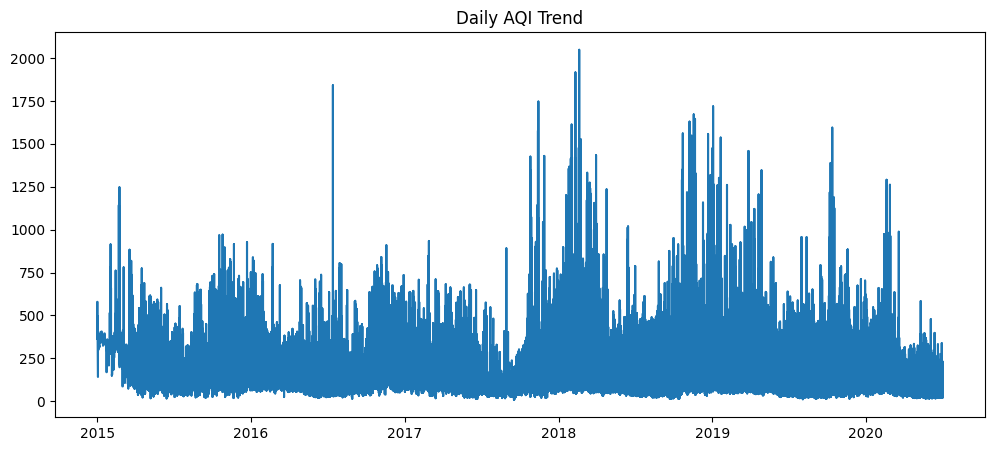

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df_day['AQI'])
plt.title("Daily AQI Trend")
plt.show()

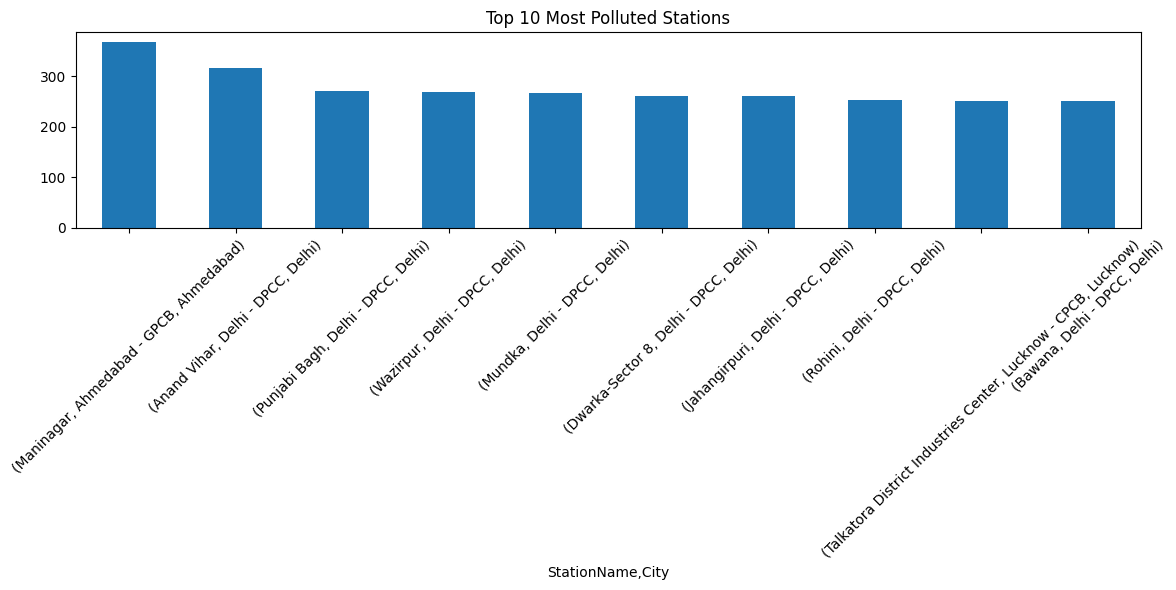

In [6]:
station_avg = df_day.groupby(['StationName', 'City'])['AQI'].mean().sort_values(ascending=False)

top_stations = station_avg.head(10)

plt.figure(figsize=(12,6))
top_stations.plot(kind='bar')

plt.title("Top 10 Most Polluted Stations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

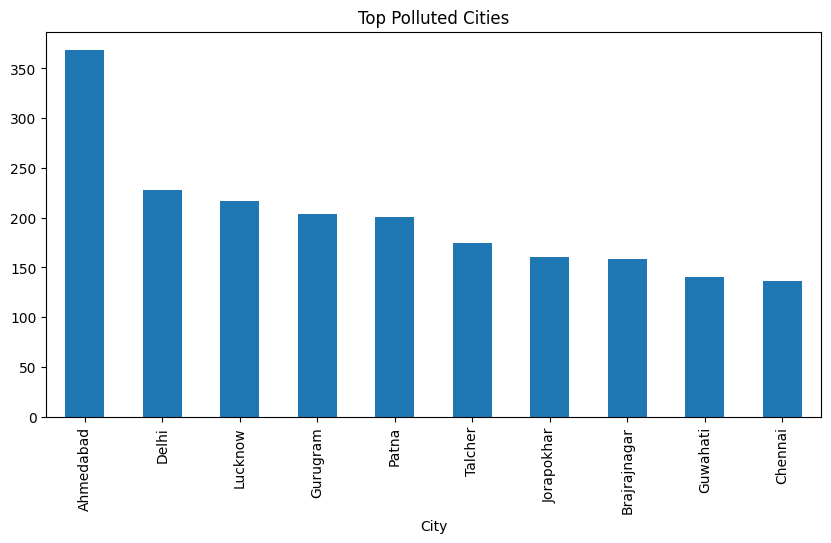

In [7]:
city_avg = df_day.groupby('City')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
city_avg.head(10).plot(kind='bar')

plt.title("Top Polluted Cities")
plt.show()

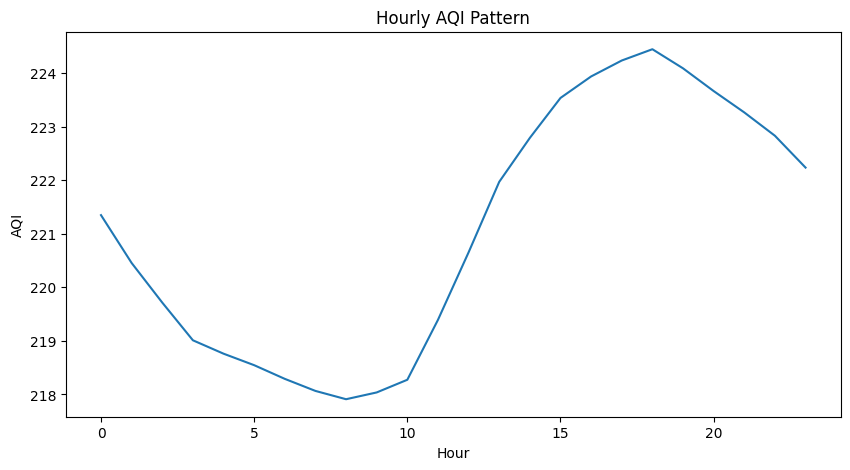

In [8]:
# Convert to datetime
df_hour['Datetime'] = pd.to_datetime(df_hour['Datetime'])

# Set index
df_hour.set_index('Datetime', inplace=True)

# Extract hour
df_hour['hour'] = df_hour.index.hour

# Group
hourly_avg = df_hour.groupby('hour')['AQI'].mean()

# Plot
plt.figure(figsize=(10,5))
plt.plot(hourly_avg)

plt.title("Hourly AQI Pattern")
plt.xlabel("Hour")
plt.ylabel("AQI")

plt.show()

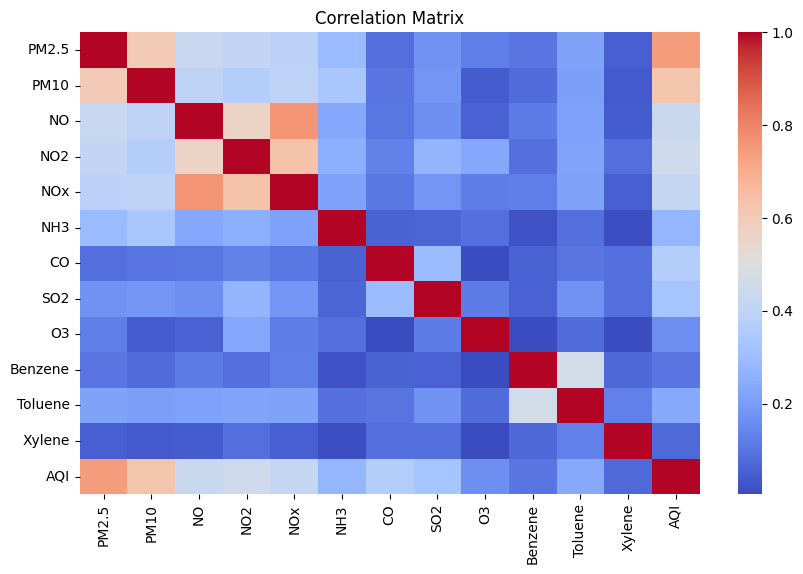

In [9]:
sample_df = df_day.select_dtypes(include=['number']).sample(10000)

plt.figure(figsize=(10,6))
sns.heatmap(sample_df.corr(), cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [10]:
df = df_hour.copy()

df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['weekday'] = df.index.weekday

df['lag_1'] = df['AQI'].shift(1)
df['lag_24'] = df['AQI'].shift(24)

df['rolling_mean_24'] = df['AQI'].rolling(24).mean()
df['rolling_std_24'] = df['AQI'].rolling(24).std()

df = df.dropna()

In [11]:
df = df.sample(50000, random_state=42)

In [12]:
df_model = df.select_dtypes(include=['number'])

X = df_model.drop(columns=['AQI'])
y = df_model['AQI']

split = int(len(df_model) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = RandomForestRegressor(n_estimators=50)  # reduced for speed
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))

MAE: 3.365182


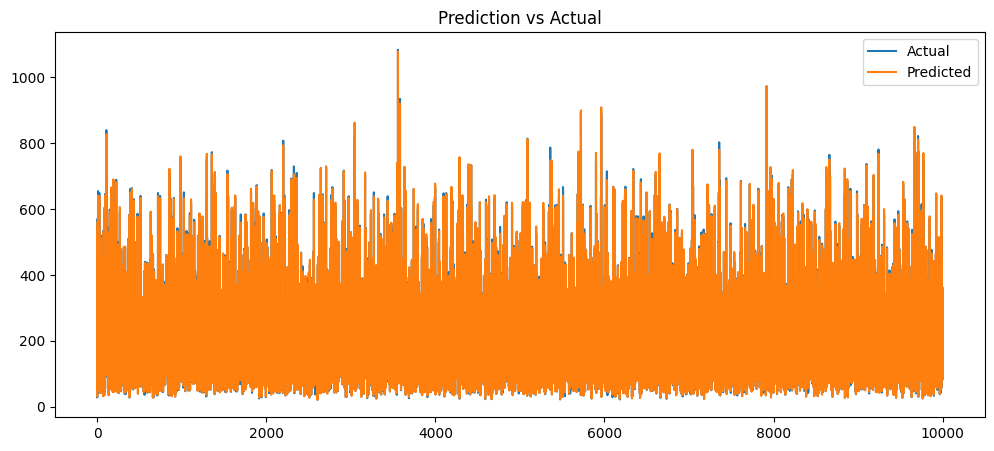

In [13]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(preds, label='Predicted')

plt.legend()
plt.title("Prediction vs Actual")
plt.show()

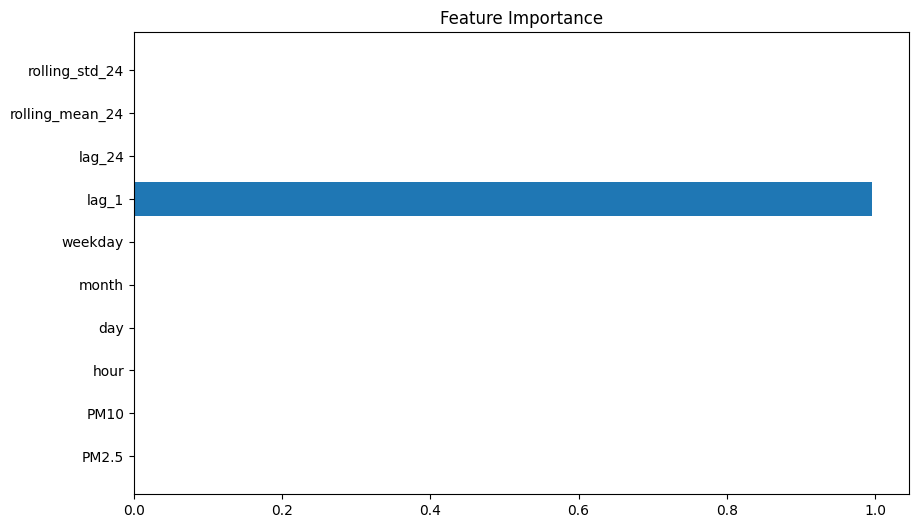

In [14]:
importances = model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)

plt.title("Feature Importance")
plt.show()

In [15]:
mean = df['AQI'].mean()
std = df['AQI'].std()

df['z_score'] = (df['AQI'] - mean) / std
df['anomaly'] = np.where(abs(df['z_score']) > 3, 1, 0)

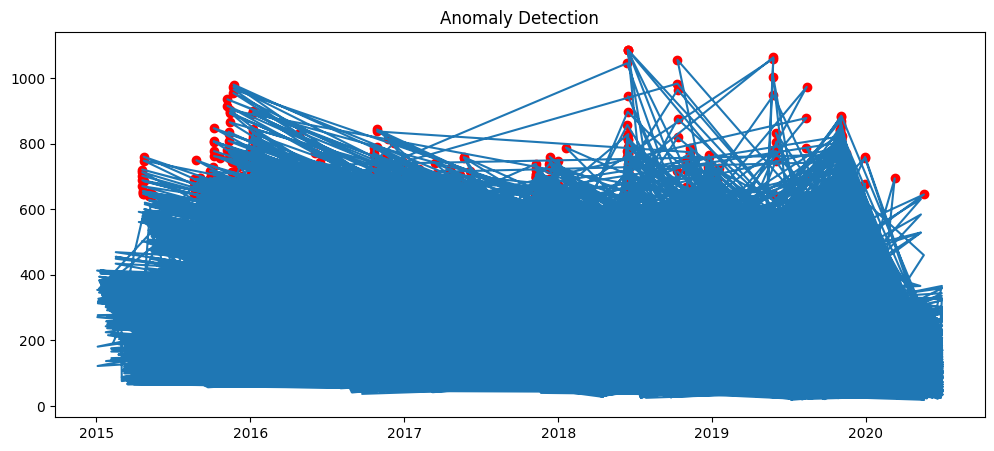

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df['AQI'])

anomalies = df[df['anomaly'] == 1]
plt.scatter(anomalies.index, anomalies['AQI'], color='red')

plt.title("Anomaly Detection")
plt.show()

In [17]:
stations.columns = stations.columns.str.strip()  # remove spaces
stations.columns = stations.columns.str.lower()  # lowercase

In [19]:
city_coords = {
    "Kolkata": [22.5726, 88.3639],
    "Delhi": [28.7041, 77.1025],
    "Mumbai": [19.0760, 72.8777],
    "Bengaluru": [12.9716, 77.5946],
    "Chennai": [13.0827, 80.2707],
    "Hyderabad": [17.3850, 78.4867],
    "Pune": [18.5204, 73.8567],
    "Ahmedabad": [23.0225, 72.5714],
    "Jaipur": [26.9124, 75.7873],
    "Lucknow": [26.8467, 80.9462],
    "Kanpur": [26.4499, 80.3319],
    "Nagpur": [21.1458, 79.0882],
    "Patna": [25.5941, 85.1376],
    "Guwahati": [26.1445, 91.7362],
    "Bhopal": [23.2599, 77.4126],
    "Indore": [22.7196, 75.8577],
    "Visakhapatnam": [17.6868, 83.2185],
    "Chandigarh": [30.7333, 76.7794],
    "Amritsar": [31.6340, 74.8723],
    "Ludhiana": [30.9010, 75.8573],
    "Varanasi": [25.3176, 82.9739],
    "Coimbatore": [11.0168, 76.9558],
    "Kochi": [9.9312, 76.2673],
    "Thiruvananthapuram": [8.5241, 76.9366],
    "Jodhpur": [26.2389, 73.0243],
    "Udaipur": [24.5854, 73.7125],
    "Kota": [25.2138, 75.8648],
    "Noida": [28.5355, 77.3910],
    "Ghaziabad": [28.6692, 77.4538],
    "Faridabad": [28.4089, 77.3178],
    "Gurugram": [28.4595, 77.0266],
    "Howrah": [22.5958, 88.2636],
    "Asansol": [23.6739, 86.9524],
    "Durgapur": [23.5204, 87.3119],
    "Siliguri": [26.7271, 88.3953]
}

In [20]:
df_day['Latitude'] = df_day['City'].map(lambda x: city_coords.get(x, [None, None])[0])
df_day['Longitude'] = df_day['City'].map(lambda x: city_coords.get(x, [None, None])[1])

In [21]:
import plotly.express as px

map_df = df_day.dropna(subset=['Latitude', 'Longitude'])

map_df = map_df.groupby('City').agg({
    'AQI': 'mean',
    'Latitude': 'first',
    'Longitude': 'first'
}).reset_index()

fig = px.scatter_map(
    map_df,
    lat="Latitude",
    lon="Longitude",
    color="AQI",
    size="AQI",
    hover_name="City",
    zoom=4,
    title="India AQI Map"
)

fig.show()

In [29]:
!pip install --upgrade nbformat


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
